@kho 


@craft https://aistudio.google.com/u/2/prompts/1JvJ2aLWfn_eLS9AXm589xI67aFxp1LZv

I wanted to play [Hollowknight: Silksong](https://store.steampowered.com/app/1030300/Hollow_Knight_Silksong/) with IRL bodily input (gestures).

### **Section 1: Data Explanation**

#### 1.1 "What is included?" - The Raw Data

This project utilizes a personal dataset of Inertial Measurement Unit (IMU) signals captured from a [Google Pixel Watch (1st Gen)](https://support.google.com/googlepixelwatch/answer/12651869): 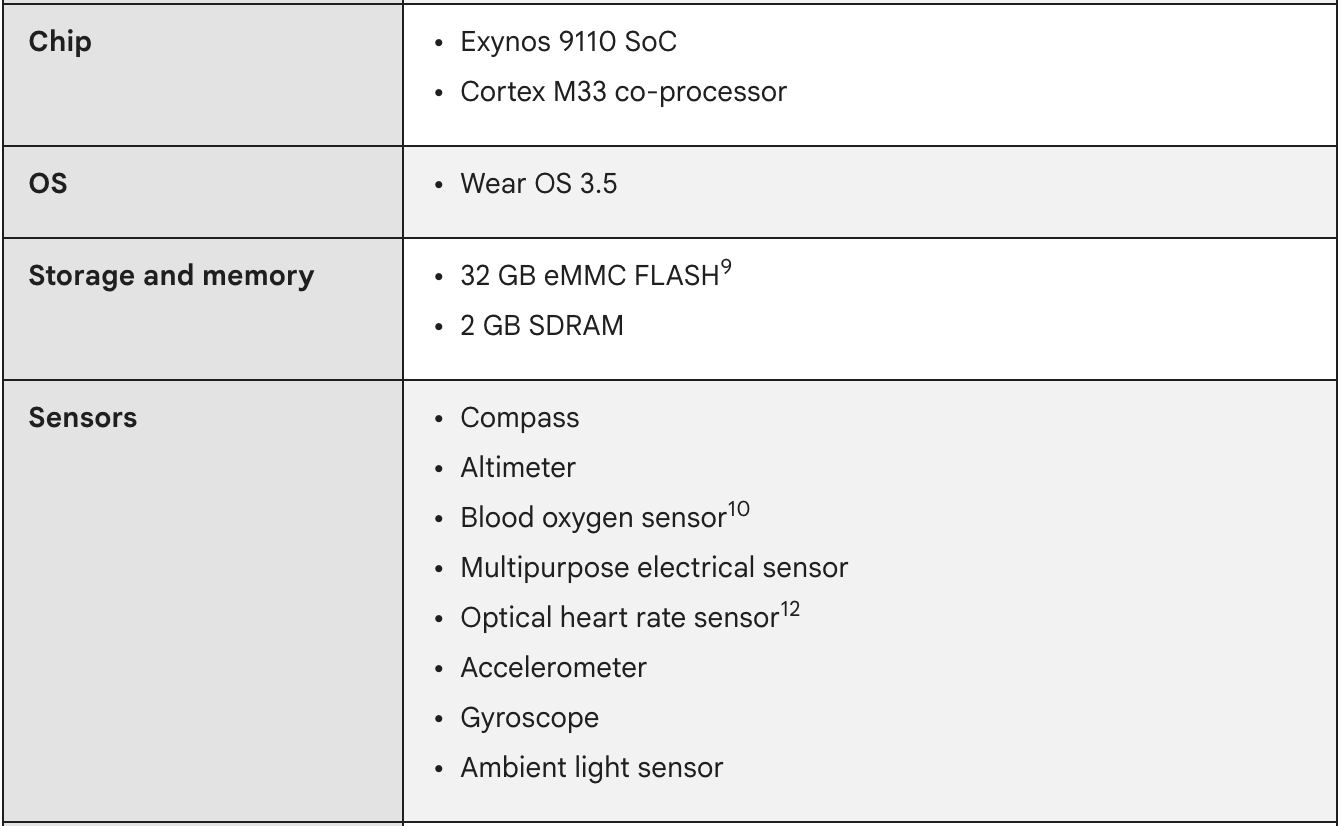

The data consists of raw, 50Hz, 9-axis sensor readings which serve as the foundational features for the classification task.

**Table 1.1: Input Features (IMU Sensor Data)**

| Sensor Group      | Axes (`_x`, `_y`, `_z`, `_w`) | Units      | Technical Notes                                                        |
| :---------------- | :---------------------------- | :--------- | :--------------------------------------------------------------------- |
| **Accelerometer** | `accel`                       | m/s²       | Measures linear acceleration. The raw signal includes the gravity vector. |
| **Gyroscope**     | `gyro`                        | rad/s      | Measures rotational velocity. Subject to integration drift over time.    |
| **Rotation Vector** | `rot`                         | Unitless   | A sensor-fused quaternion representing absolute device orientation.      |

The data is categorized into seven distinct gesture classes. The `Noise` class is crucially included to make the final model robust to the miscellaneous, non-gesture movements of real-world usage.

**Table 1.2: Output Labels (Gesture Classes)**

| Class Label    | Type      | Description & Context                      | Expected Motion Profile                                  | Samples |
| :------------- | :-------- | :----------------------------------------- | :------------------------------------------------------- | :------ |
| `Walk`         | Sustained | Arm swings during normal walking.          | Periodic accel signals; moderate gyro oscillations.      | 71      |
| `Idle`         | Sustained | Minimal movement while sitting or standing. | Low variance in accel/gyro; stable orientation.          | 120     |
| `Punch`        | Ballistic | A rapid forward thrust and retraction.     | High accel spike on primary axis; short duration.        | 120     |
| `Jump`         | Ballistic | An upward impulse followed by an impact.   | Strong vertical (`Y-axis`) accel peak; landing shock.    | 120     |
| `Turn Left`    | Ballistic | A quick leftward rotation of the wrist.    | Gyroscope peak on `Z` or `Y` axis; rotation vector shift.  | 120     |
| `Turn Right`   | Ballistic | A quick rightward rotation of the wrist.   | Opposite gyroscope peak to `Turn Left`.                  | 120     |
| `Noise`        | Stochastic| Random movements like scratching, adjusting.| Irregular, non-repeating accel/gyro patterns.            | 120     |


**Figure 1.1: Raw 9-Axis IMU Signals for a Single "Punch" Gesture**

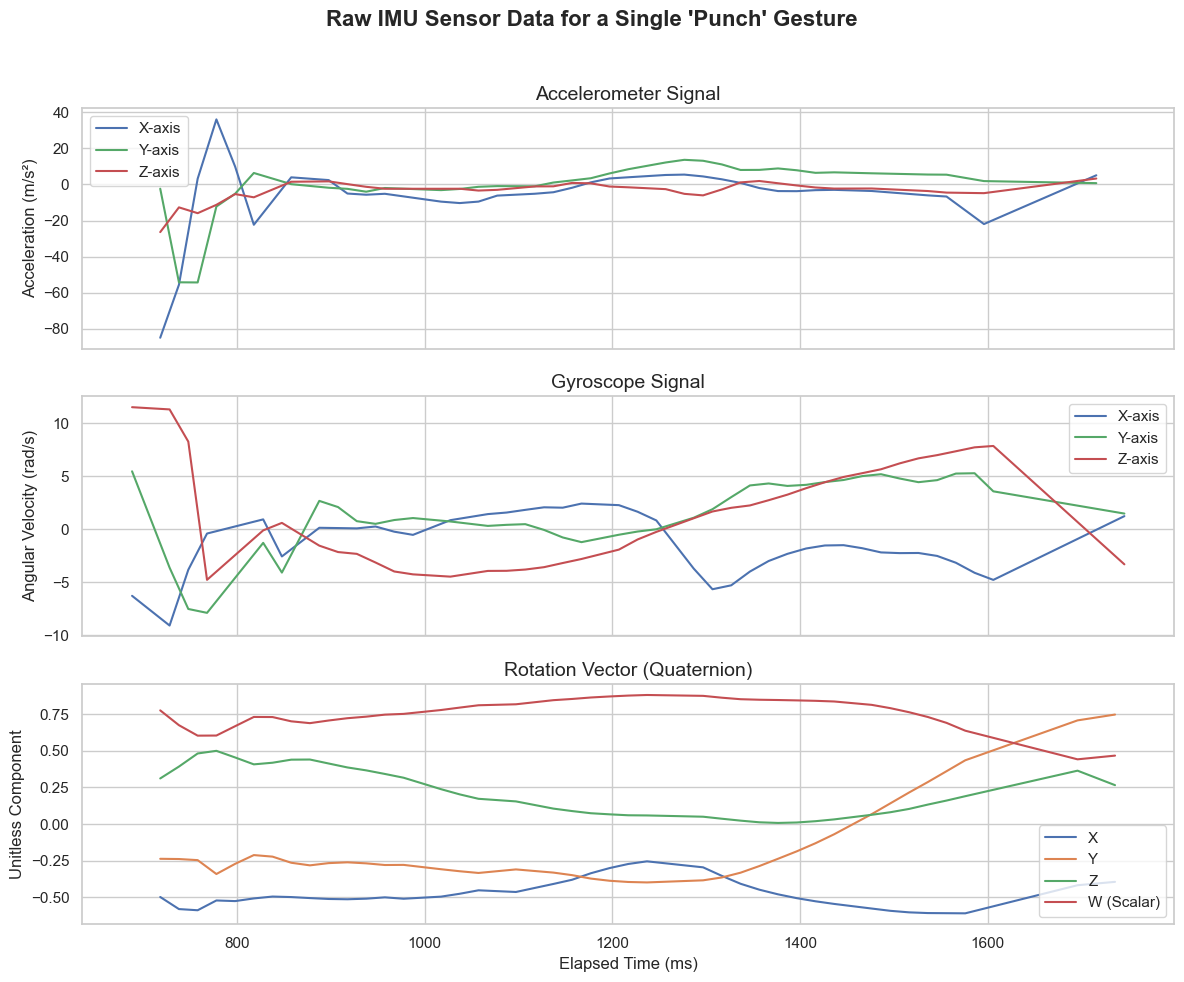

> The raw, unmerged 9-axis IMU signals from a single "Punch" gesture, which lasted approximately 1.75 seconds. These three plots show the distinct data streams that are later merged and used for feature extraction.*

-   **Top (Accelerometer):** This plot shows the most obvious pattern—a large, sharp spike in the X-axis (blue) corresponding to the forward thrust of the fist. This is the primary signature of a punch.
-   **Middle (Gyroscope):** This captures the wrist's rotation during the punch and retraction.
-   **Bottom (Rotation Vector):** This shows the change in the device's absolute orientation in 3D space as a quaternion.


**Figure 1.2: Time-Aligned IMU Signals After Preprocessing**

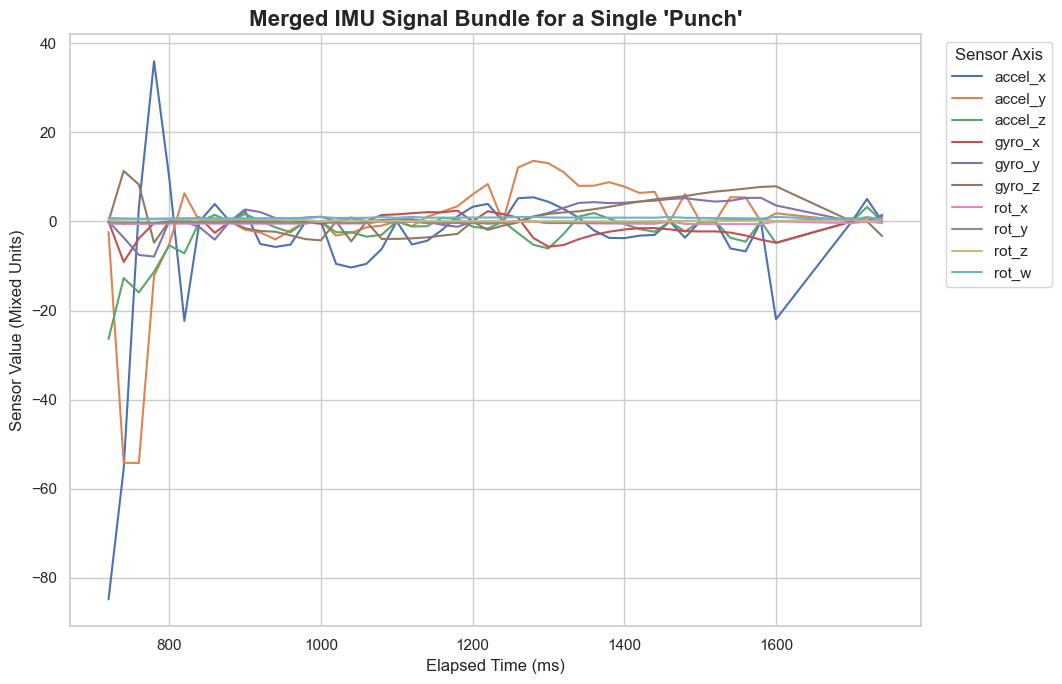

> The same "Punch" gesture as shown previously, but after being processed by the `merge_sensor_rows.py` script. The separate, sparse sensor streams have been successfully time-aligned into a single, dense data structure.

This merged format is the direct input for the feature extraction stage. The characteristic spike in the accelerometer's X-axis (top plot, blue line) is still clearly visible, but now all 9 axes of data are synchronized to a common time base, making statistical and spectral analysis possible.

Visualizing the data this way confirms the presence of distinct, high-frequency patterns that a machine learning model can be trained to recognize.


#### 1.2 "How was it obtained?" - A Custom Data Collection Pipeline

My initial attempt to collect this data using voice commands for labeling failed (achieving <30% accuracy) due to severe timestamp misalignment issues. This demonstrated that obtaining high-quality data from my own digital archive required an engineered solution. To solve this, I developed a custom three-device pipeline from scratch.

**Figure 1.2: The Data Collection Setup in Action**

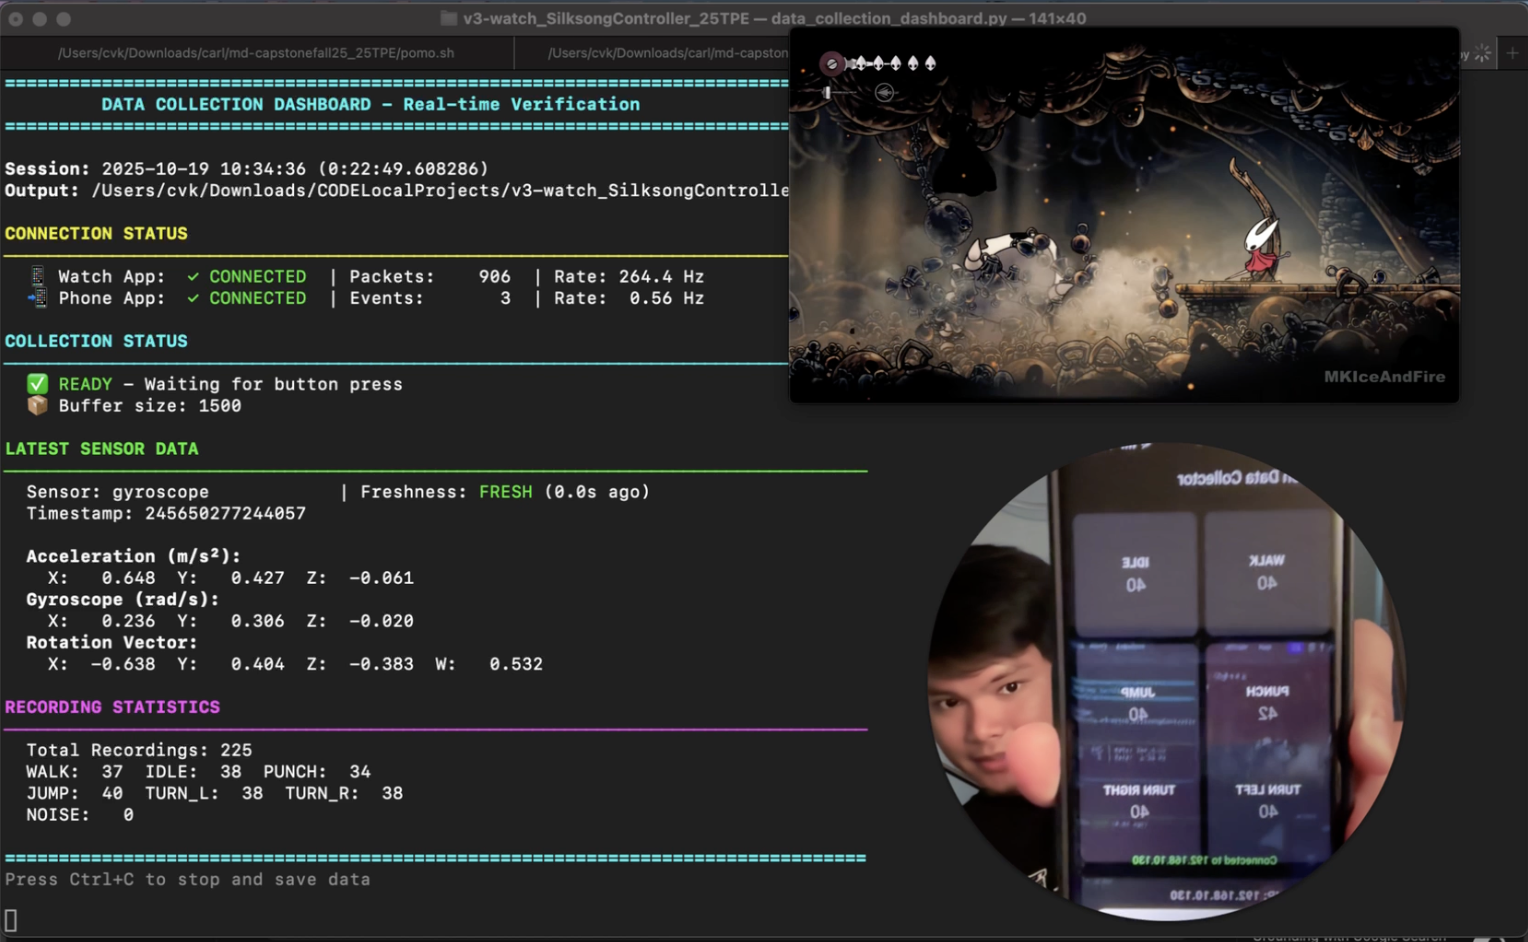

> *The full data collection setup. A [custom app on the Pixel Watch](https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE/tree/main/Android) (left wrist) streams IMU data. It is labeled in real-time using a second custom application on the Android Phone (right hand). A Python script on the MacBook listens for and synchronizes both data streams into a final, labeled CSV file. [Full Loom video explainer here.](https://www.loom.com/share/2916e39c95144d83a64ec4251d7f6b09?sid=8dd19f81-7540-4c9b-a7ce-96dacf7c9267)*

The [Android labeling app](https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE/tree/main/Android_2_Grid) includes a **press-and-hold mechanic** for millisecond-precise temporal boundaries and **real-time sample counts** to ensure I was building a balanced dataset during the collection process. Its design directly addresses the failures of the voice-based approach.


#### 1.3 "Important details about how it was sampled" - Methodology and Structure

Each gesture was performed and labeled individually while modelling real gameplay. **How?** I performed the gestures while watching gameplay footage. I chose to embed the label and timestamps directly into each filename. This makes the data transparent and less prone to the corruption that can affect column-based labels.


A single sample in my dataset is a time series matrix with a variable number of rows (corresponding to the gesture's duration) and 10 columns (timestamp + 9 sensor axes).


In [15]:
import pandas as pd
from pathlib import Path

# Load and display the structure of a single time series matrix
sample_df = pd.read_csv(
    Path(
        "data/organized_training/multiclass_classification/punch/punch_1760926656847_to_1760926657657.csv"
    )
)
print(f"Shape of this sample matrix (rows, columns): {sample_df.shape}")
display(sample_df.head(5))

Shape of this sample matrix (rows, columns): (38, 11)


,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,rot_w,rot_x,rot_y,rot_z
0,1643900000000,-6.322761,16.262194,-5.670425,0.000000,0.000000,0.000000,0.758317,-0.474125,-0.107004,-0.434408
1,1643920000000,-24.370754,14.715076,2.162301,-1.552056,3.132975,12.023508,0.796346,-0.480570,-0.021338,-0.366648
2,1643940000000,-73.839980,8.888604,-4.926035,-1.811674,3.247054,14.206893,0.832197,-0.474486,0.083541,-0.274467
3,1643960000000,-67.503900,-13.528680,-17.359951,-2.494010,-7.850382,9.366397,0.851718,-0.484384,0.126639,-0.154632
4,1643980000000,-15.888457,-39.420364,-40.197190,-9.568440,-7.500509,3.975053,0.849756,-0.519578,0.076178,-0.046365


Following the collection of hundreds of raw samples, I performed a manual curation pass, deleting clear errors (e.g., accidental button taps, incorrectly performed gestures) to improve the overall quality of the training set. The final dataset consists of **791 curated samples**, carefully balanced across the classes.

Finally, regarding ethical considerations: as the dataset is `n=1` (my own biosignals) and processed locally, no immediate privacy issues exist. However, I acknowledge that any attempt to scale this work would require a rigorous informed consent process to address the risk of IMU data acting as a biometric identifier.

### **Section 2: Data Conversion and Loading**

#### 2.1 "…converting this data to python readable format…" - The Loading Pipeline

My data exists as a collection of individual `.csv` files, each named after the gesture it contains. To make this data useful for a machine learning model, I needed to write a robust function to convert this file-based structure into a standard, in-memory format.

First, to provide context for the code, this is the directory structure I designed it to parse.

**Figure 2.1: Organized Data Directory Structure**
```markdown
data/organized_training/
└── multiclass_classification/
    ├── punch/
    │   └── punch_1760926656847_to_1760926657657.csv
    ├── jump/
    │   └── ...
    ├── turn_left/
    │   └── ...
    ├── turn_right/
    │   └── ...
    ├── idle/
    │   └── ...
    └── noise/
        └── ...
```
> The organized directory structure for the training data. Each gesture class has its own subdirectory containing multiple `.csv` files, each representing a single recorded sample of that gesture.*

The following Python code is my implementation for this conversion. I wrote it to be resilient, handling potential issues like empty or corrupted files without crashing. A necessary precaution after seeing some errors during my initial data collection.


In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# I chose to use Python's built-in logging to provide clean status updates,
# which is more flexible than using simple print statements.
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")


def load_data_from_directory(data_dir: Path, classes: list):
    """
    I wrote this function to scan a directory for CSV files, parse the class
    label from the folder structure, and load the time-series data into memory.

    It's designed to be robust, skipping corrupted or empty files gracefully.
    """
    all_features = []
    all_labels = []

    logging.info(f"Scanning directory: {data_dir}")

    for class_index, class_name in enumerate(classes):
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            logging.warning(f"Directory not found for class '{class_name}', skipping.")
            continue

        file_paths = list(class_dir.glob("*.csv"))
        logging.info(f"Found {len(file_paths)} files for class '{class_name}'.")

        for file_path in file_paths:
            try:
                df = pd.read_csv(file_path)

                # Data Quality Check: I noticed that accidental, short button presses
                # created invalid samples. I decided that any recording shorter than
                # 200ms (10 samples at 50Hz) should be discarded as noise.
                if len(df) < 10:
                    logging.warning(
                        f"Skipping short file (likely a mis-tap): {file_path.name}"
                    )
                    continue

                # The timestamp is used for visualization but is not a feature for the model,
                # so I drop it here before converting to a NumPy array.
                features = df.drop(columns=["timestamp"]).values

                all_features.append(features)
                all_labels.append(class_index)

            # This handles cases where a file might be empty or improperly formatted.
            except pd.errors.ParserError:
                logging.error(f"Skipping malformed CSV file: {file_path.name}")
            except Exception as e:
                logging.error(
                    f"An unexpected error occurred with {file_path.name}: {e}"
                )

    logging.info(f"Load complete. Assembled {len(all_features)} valid samples.")
    return all_features, np.array(all_labels)

#### 2.2 "…loading this data into an appropriate data structure…" - Verification

To verify the function works, I executed it on my `multiclass_classification` dataset. The code below calls the function and then prints the type and shape of the resulting Python objects.

This output serves as proof that the raw files have been successfully converted into the data structures needed for scikit-learn: a list of NumPy arrays for the features (`X`) and a single NumPy array for the labels (`y`).

![Data Loading Flowchart](data_loading_flowchart.png)

In [18]:
# --- Configuration ---
DATA_ROOT = Path("data/organized_training/")
MULTICLASS_DIR = DATA_ROOT / "multiclass_classification"
MULTICLASS_CLASSES = ["punch", "jump", "turn_left", "turn_right", "idle", "noise"]

# --- Execution & Verification ---
X_multi, y_multi = load_data_from_directory(MULTICLASS_DIR, MULTICLASS_CLASSES)

print("\n --- VERIFICATION OUTPUT ---")
print(f"Resulting type of X: {type(X_multi)}")
print(f"Number of samples loaded: {len(X_multi)}")
# Note: Gestures have variable lengths, so we inspect the first one as an example.
print(f"Shape of first sample in X: {X_multi[0].shape if X_multi else 'N/A'}")
print(f"Resulting type of y: {type(y_multi)}")
print(f"Shape of the label vector y: {y_multi.shape}")

INFO: Scanning directory: data/organized_training/multiclass_classification
INFO: Found 120 files for class 'punch'.
INFO: Found 120 files for class 'jump'.
INFO: Found 120 files for class 'turn_left'.
INFO: Found 120 files for class 'turn_right'.
INFO: Found 120 files for class 'idle'.
INFO: Found 120 files for class 'noise'.
INFO: Load complete. Assembled 720 valid samples.



 --- VERIFICATION OUTPUT ---
Resulting type of X: <class 'list'>
Number of samples loaded: 720
Shape of first sample in X: (54, 10)
Resulting type of y: <class 'numpy.ndarray'>
Shape of the label vector y: (720,)


### **Section 3: Pre-processing, and Feature Engineering**

#### 3.1 "…explaining…feature engineering the data requires…" - The Necessity of Feature Engineering

The raw IMU data, even after being merged, is not directly usable by a classic machine learning model like an SVM. A single "punch" gesture can be a matrix of over 70 timesteps and 9 sensor axes, resulting in 630+ raw numbers. 

Feeding this directly to a model would create two immediate problems:

1.  **The Curse of Dimensionality:** I have far more features (630+) than samples (~120 per class), which is a classic recipe for overfitting.
2.  **The Variable-Length Problem:** Not all gestures take the same amount of time. A short punch and a long punch would have different matrix shapes, making it impossible to stack them for training.

The solution is not to use the raw data, but to engineer features from it. I needed to write a function that could take any variable-length time-series gesture and distill it into a **fixed-length vector of descriptive statistics**. This vector would capture the essential statistical and spectral "fingerprint" of the motion.

My strategy was to extract features from two domains, a standard practice in sensor-based activity recognition:

*   **Time-Domain Features:** Statistics that describe the signal's shape and magnitude over time (e.g., mean, standard deviation, skew).
*   **Frequency-Domain Features:** Statistics that describe the signal's periodic or transient nature, calculated using the Fast Fourier Transform (FFT).



#### 3.2 "…a code block completing these steps…" - Feature Extraction Implementation

Here is the function I wrote, `extract_features`, which takes a single gesture's DataFrame and returns a dictionary of 48 features (8 features for each of the 6 primary accel/gyro axes).

I chose to focus on the accelerometer and gyroscope axes as they capture the motion dynamics most directly. The rotation vector was less useful for this specific task.


In [21]:
import pandas as pd
import numpy as np
from scipy.fft import rfft
from scipy.stats import skew, kurtosis


def extract_features(df: pd.DataFrame) -> dict:
    """
    I wrote this function to transform a single time-series gesture into a
    fixed-length feature vector. It calculates 8 statistical and spectral
    features for each of the 6 primary sensor axes.
    """
    features = {}

    # I decided to process each of the 6 axes independently to capture
    # the unique dynamics of each direction of motion.
    for axis in ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]:
        signal = df[axis].dropna()

        # --- Data Cleaning ---
        # If a signal is empty after dropping NaNs, I fill its features with 0.0
        # to prevent downstream errors.
        if len(signal) < 3:  # Need at least 3 points for robust stats/FFT
            for stat in [
                "mean",
                "std",
                "min",
                "max",
                "skew",
                "kurtosis",
                "fft_max",
                "fft_mean",
            ]:
                features[f"{axis}_{stat}"] = 0.0
            continue

        # --- Time-Domain Feature Extraction ---
        features[f"{axis}_mean"] = signal.mean()
        features[f"{axis}_std"] = signal.std()
        features[f"{axis}_min"] = signal.min()
        features[f"{axis}_max"] = signal.max()
        features[f"{axis}_skew"] = skew(signal)  # Measures asymmetry
        features[f"{axis}_kurtosis"] = kurtosis(signal)  # Measures "peakedness"

        # --- Frequency-Domain Feature Extraction ---
        # I use rfft (Real FFT) because my signal is real-valued, which is more efficient.
        fft_vals = np.abs(rfft(signal.to_numpy()))

        # Per the Nyquist theorem, only the first half of the FFT coefficients are unique.
        fft_vals = fft_vals[: len(signal) // 2]

        if fft_vals.size > 0:
            features[f"{axis}_fft_max"] = np.max(
                fft_vals
            )  # Dominant frequency component
            features[f"{axis}_fft_mean"] = np.mean(fft_vals)  # Average frequency power
        else:
            features[f"{axis}_fft_max"] = 0.0
            features[f"{axis}_fft_mean"] = 0.0

    return features


#### 3.3 "…perform some basic exploratory data analysis…" - Proving the Features Work

Feature engineering is only useful if the resulting features actually help to separate the classes. To prove this, I performed an Exploratory Data Analysis (EDA). I loaded my `binary_classification` dataset (`walk` vs. `idle`), applied my `extract_features` function to every sample, and then visualized the results.

First, I needed to load the data and build the feature matrix.|

In [26]:
# --- Load Raw Data (from Section 2) ---
DATA_ROOT = Path("data/organized_training/")
BINARY_DIR = DATA_ROOT / "binary_classification"
BINARY_CLASSES = ["walk", "idle"]
X_raw_list, y_binary = load_data_from_directory(BINARY_DIR, BINARY_CLASSES)

# --- Build Feature Matrix ---
# I create a temporary DataFrame for each sample to pass to my function.
feature_list = []
for sample_array in X_raw_list:
    sample_df = pd.DataFrame(
        sample_array,
        columns=[
            "accel_x",
            "accel_y",
            "accel_z",
            "gyro_x",
            "gyro_y",
            "gyro_z",
            "rot_x",
            "rot_y",
            "rot_z",
            "rot_w",
        ],
    )
    features = extract_features(sample_df)
    feature_list.append(features)

# The final feature matrix, X, is a pandas DataFrame.
X_binary = pd.DataFrame(feature_list)

print("\n --- EDA SETUP COMPLETE ---")
print(f"Shape of final feature matrix X: {X_binary.shape}")
print(f"Shape of final label vector y: {y_binary.shape}")

INFO: Scanning directory: data/organized_training/binary_classification
INFO: Found 71 files for class 'walk'.
INFO: Found 120 files for class 'idle'.
INFO: Load complete. Assembled 191 valid samples.



 --- EDA SETUP COMPLETE ---
Shape of final feature matrix X: (191, 48)
Shape of final label vector y: (191,)


With the feature matrix `X_binary` built, I could now visualize the features to check for class separation.

**Figure 3.1: Class Separability in Key Engineered Features**
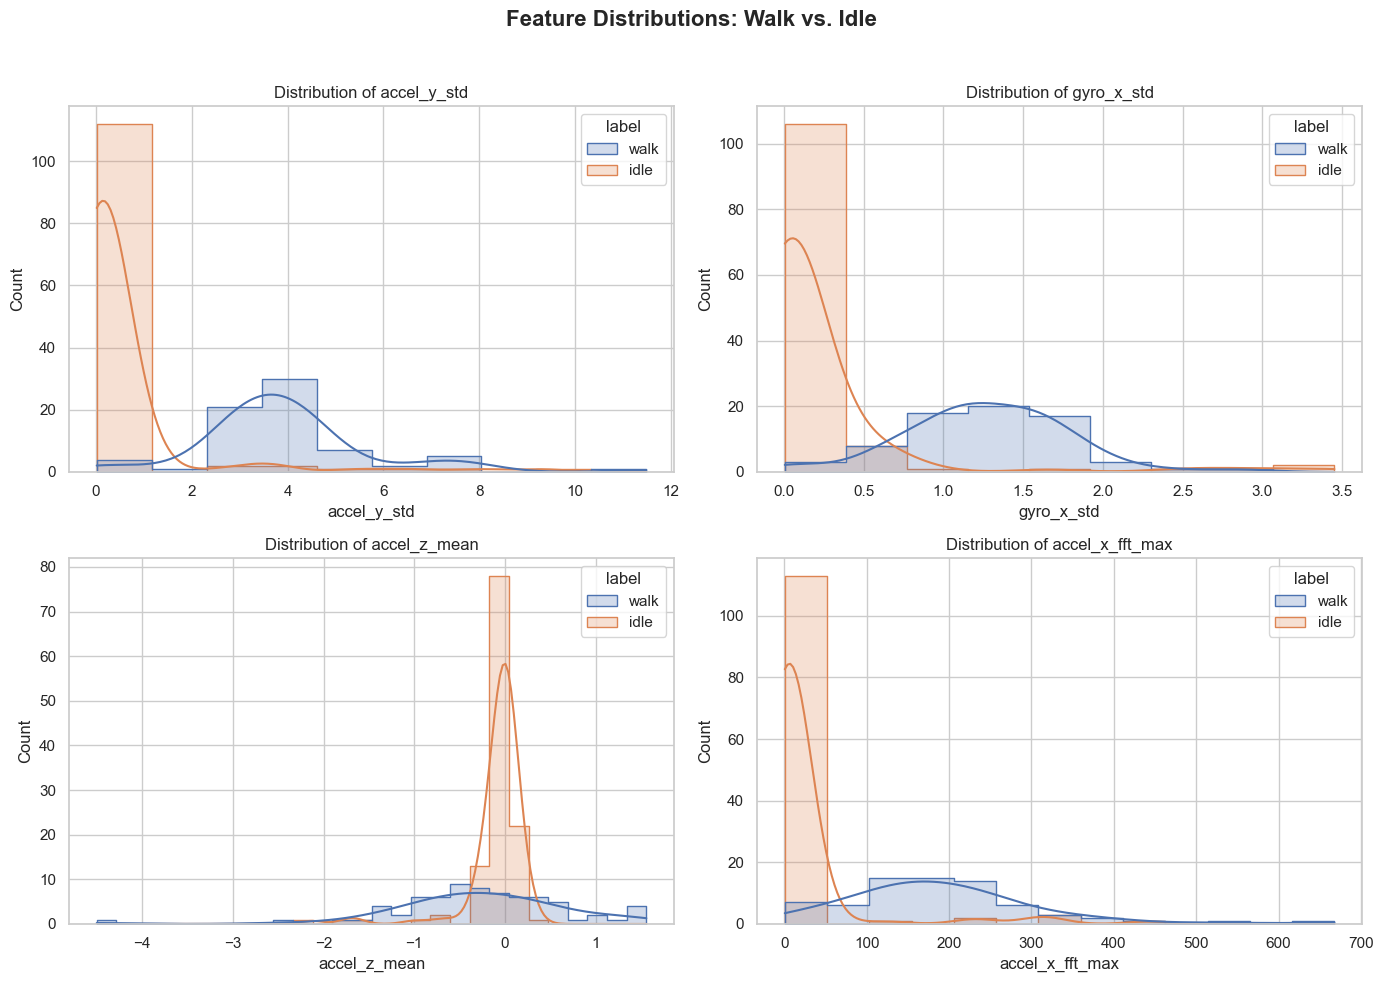

> A comparison of the distributions for four key features, separated by the walk (orange) and idle (blue) classes. This plot serves as the primary visual proof that my feature engineering was successful.

The clear separation between the distributions is the key takeaway. For example, in the `accel_y_std` plot (standard deviation of vertical acceleration - top left), the feature values for idle are tightly clustered near zero, while the values for walk form a distinct, higher-variance distribution. It is consistently low for `idle` and high for `walk`, as I expected. 

Finally, to check for redundancy among my 48 features, I plotted a correlation matrix.

**Figure 3.2: Feature Correlation Matrix**

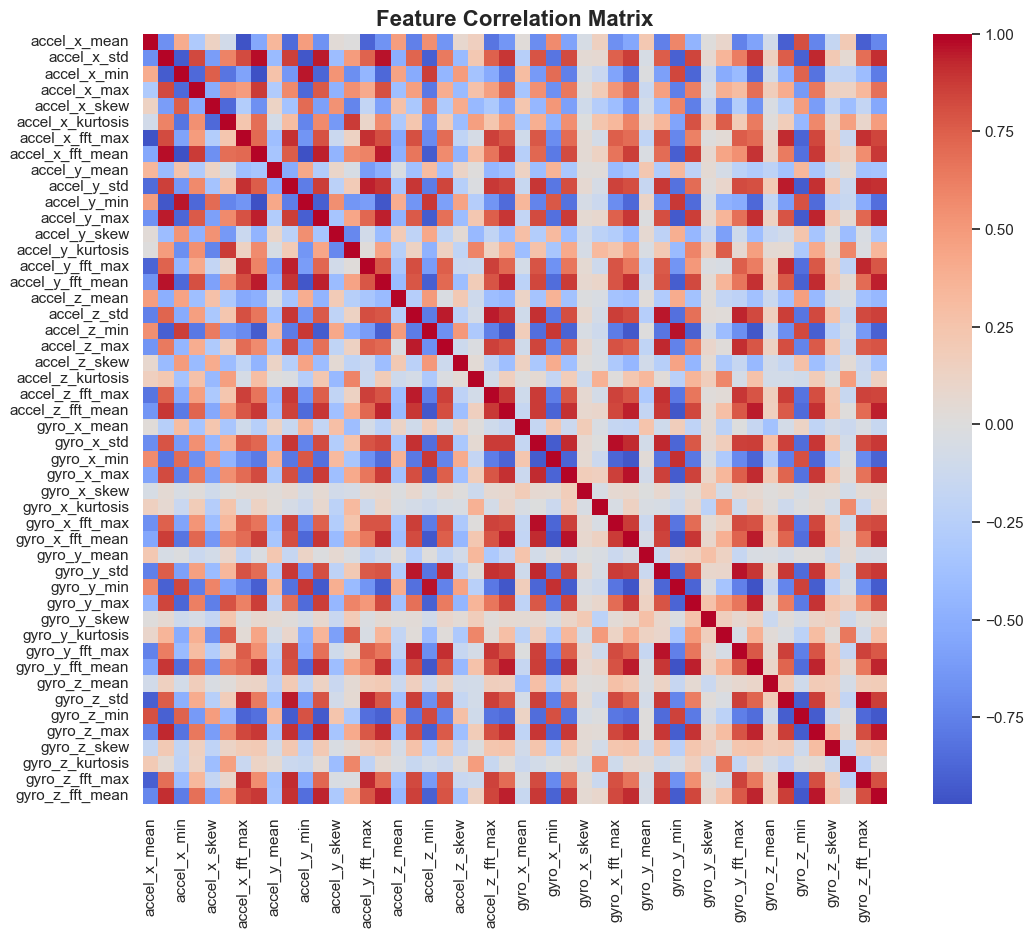

> A heatmap of the Pearson correlation matrix for all 48 engineered features. The purpose of this analysis is to understand the relationships and potential redundancies within my feature set.

The blocks of high correlation (bright red) along the diagonal are expected; features derived from the same sensor axis (e.g., `accel_x_mean` and `accel_x_std`) naturally share some information. However, the relatively low correlation between different sensor groups (e.g., the block between accelerometer and gyroscope features) is a positive sign. It indicates that the different sensors are capturing independent aspects of the motion. 

This diversity justifies using the full feature set, as it provides a rich, multi-faceted description of each gesture for the model to learn from.

### **Section 4: Analysis Plan and Data Splitting**

#### 4.1 "…discussing the analysis that will be conducted…" - A Tale of Two Classification Tasks

The fundamental goal of this project is to assign a discrete, predefined label (like `punch` or `walk`) to a given window of IMU sensor data. This is, by definition, a **supervised classification** problem.

However, as I identified during my initial exploratory analysis in Section 1, my data contains two fundamentally different types of motion: sustained, periodic states (`walk`, `idle`) and short, ballistic events (`punch`, `jump`). A single model designed to recognize both would be a poor compromise.

Therefore, I made the architectural decision to split the problem into two independent classification tasks. This allows me to tailor the feature engineering, model selection, and evaluation for each specific motion profile.
 


**Figure 4.1: The Dual-Classifier Pipeline Architecture**


![](dual_classifier_pipeline.png)


> A conceptual diagram of my analysis pipeline. After the initial data loading and feature extraction, the process splits into two completely independent streams. Each stream has its own dedicated data split, model training, and evaluation, allowing for specialized solutions to each sub-problem.*

The two distinct tasks are:
1.  **Binary Classification:** A model trained to distinguish between the two sustained locomotion states: `walk` vs. `idle`.
2.  **Multiclass Classification:** A separate model trained to recognize the six discrete, ballistic actions: `punch`, `jump`, `turn_left`, `turn_right`, `idle`, and `noise`.

Each of these tasks will be handled as a separate, self-contained machine learning problem from this point forward.



#### 4.2 "…performs any necessary data splits…" - Creating Train and Test Sets

To properly evaluate my models, I need to test their performance on data they have never seen before. This prevents me from simply testing how well a model memorized the training data and instead measures its ability to generalize to new, unseen examples.

I used scikit-learn's `train_test_split` utility to perform this step. I made three key decisions in its implementation:

1.  **Test Size (30%):** I chose a standard 70/30 split. This reserves a statistically significant portion of the data for testing while leaving the majority for model training.
2.  **Stratification:** This is the most critical parameter. I set `stratify=y` to ensure that the proportion of each class in the training and testing sets is identical to the proportion in the original dataset. This is helped me prevent a biased evaluation.
3.  **Reproducibility:** I set a fixed `random_state`. This guarantees that anyone running this notebook will get the exact same train/test split, ensuring the results are reproducible.

The code block below demonstrates this process for the binary classification task:

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Note: The feature matrices (X_binary, X_multi) and label vectors (y_binary, y_multi)
# are assumed to have been created by the feature engineering steps in Section 3.

# --- Sanity Check: Print shapes before splitting ---
print("--- Data Shapes Before Split ---")
# Using pandas DataFrame .shape for binary as it was created for EDA
print(f"Binary Task - X_binary shape: {X_binary.shape}")
print(f"Binary Task - y_binary shape: {y_binary.shape}")
# Using len() for multiclass as it's a list of arrays
print(f"Multiclass Task - Number of samples: {len(X_multi)}")
print(f"Multiclass Task - y_multi shape: {y_multi.shape}")


# --- 1. Binary Classifier Data Split ---

# I use a fixed 'random_state' to ensure that this split is identical
# every time the notebook is run. This makes my results reproducible.
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.3,  # I chose a 30% test set for a robust evaluation.
    random_state=67,  # https://en.wikipedia.org/wiki/6-7_(meme)
    stratify=y_binary,  # stratify=y is critical for maintaining class balance.
)

# --- 2. Multiclass Classifier Data Split ---

# I apply the exact same splitting strategy to my multiclass data.
# The data is split independently from the binary task.
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)


# --- Verification ---
print("\n \n --- Verification of Splits ---")
print("Binary Split:")
print(f"  Training samples: {len(X_train_bin)}")
print(f"  Test samples:     {len(X_test_bin)}")
print(
    f"  Class distribution in training set (y_train_bin): \n{np.bincount(y_train_bin)}"
)
print(f"  Class distribution in test set (y_test_bin): \n{np.bincount(y_test_bin)}")

print("\n Multiclass Split:")

# Since X_multi is a list of arrays, we use len()
print(f"  Training samples: {len(X_train_multi)}")
print(f"  Test samples:     {len(X_test_multi)}")
print(
    f"  Class distribution in training set (y_train_multi): \n{np.bincount(y_train_multi)}"
)
print(f"  Class distribution in test set (y_test_multi): \n{np.bincount(y_test_multi)}")

--- Data Shapes Before Split ---
Binary Task - X_binary shape: (191, 48)
Binary Task - y_binary shape: (191,)
Multiclass Task - Number of samples: 720
Multiclass Task - y_multi shape: (720,)

 
 --- Verification of Splits ---
Binary Split:
  Training samples: 133
  Test samples:     58
  Class distribution in training set (y_train_bin): 
[49 84]
  Class distribution in test set (y_test_bin): 
[22 36]

 Multiclass Split:
  Training samples: 504
  Test samples:     216
  Class distribution in training set (y_train_multi): 
[84 84 84 84 84 84]
  Class distribution in test set (y_test_multi): 
[36 36 36 36 36 36]


**Figure 4.2: Stratified Split Preserves Class Distribution**


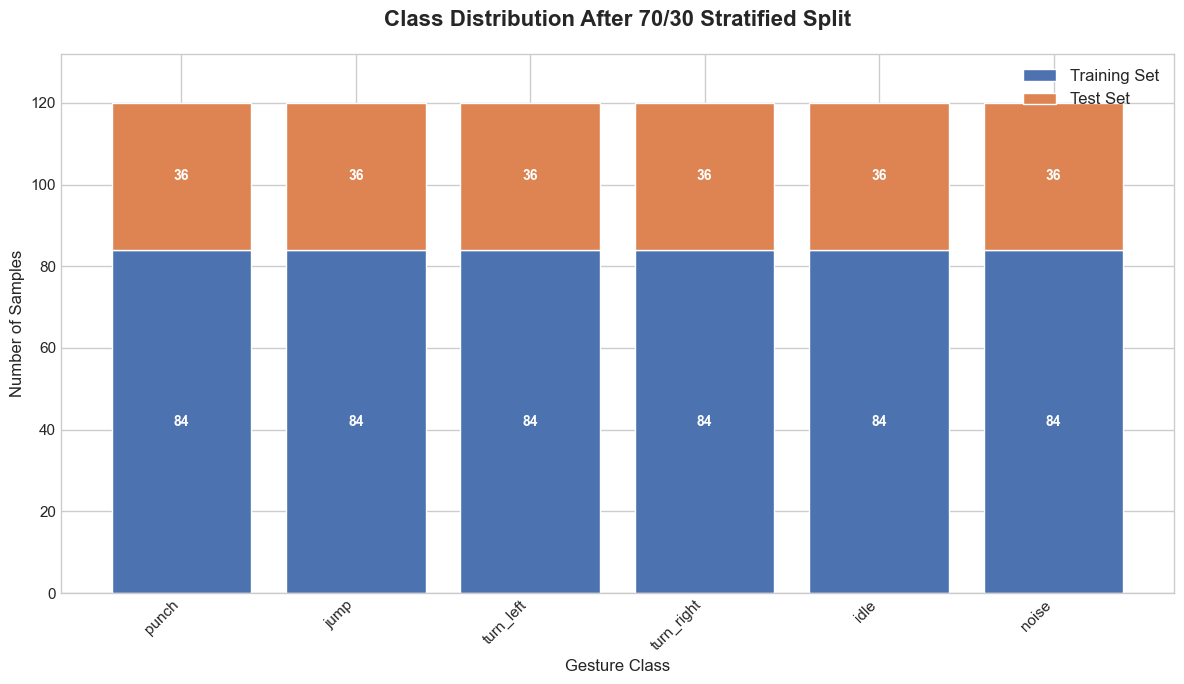

> The number of samples per class for the multiclass dataset after my 70/30 train-test split. The blue portion of each bar represents the samples allocated to the training set, while the orange portion represents the test set. 

The consistent ratio of blue to orange across all six classes is a direct result of using a stratified split. This ensures that the model is trained and evaluated on a representative distribution of the data, which is essential for a fair and accurate assessment of its performance.

### **Section 5: Model Selection and Construction**

#### 5.1 "…discuss model selection…" - Why I Chose a Support Vector Machine

For this classification task, I chose a **Support Vector Machine (SVM)**. This was a deliberate decision made after considering several alternatives for my specific problem, which is characterized by a high-dimensional feature space (48 features) and a relatively small number of training samples.

My exploratory data analysis revealed complex, non-linear relationships between features. A simple linear model like Logistic Regression would likely fail to find an effective decision boundary. While tree-based models are powerful, SVMs are particularly well-suited to finding a clear margin of separation in high-dimensional space, which is exactly the problem of distinguishing subtle gesture patterns. Given my limited dataset size, a data-hungry approach like a neural network would be prone to overfitting.

#### 5.2 "…model's mathematical underpinnings…typeset equations…" - The Mathematics of SVMs

My understanding of SVMs is heavily informed by the intuitive, visual explanations provided by Josh Starmer's StatQuest series. The core concepts are the maximum margin, the soft margin, and the kernel trick.

**The Core Idea: The Maximum Margin**

An SVM finds the *optimal* hyperplane that maximizes the distance to the nearest data point from either class. This distance is called the **margin**. The points that lie on the edge of this margin are the **support vectors**, as they are the critical data points that "support" or define the decision boundary.

I projected my 48-dimensional feature set down to two dimensions using PCA and trained a basic linear SVM.

**Figure 5.1: The Maximum Margin Principle on My Data (2D PCA Projection)**

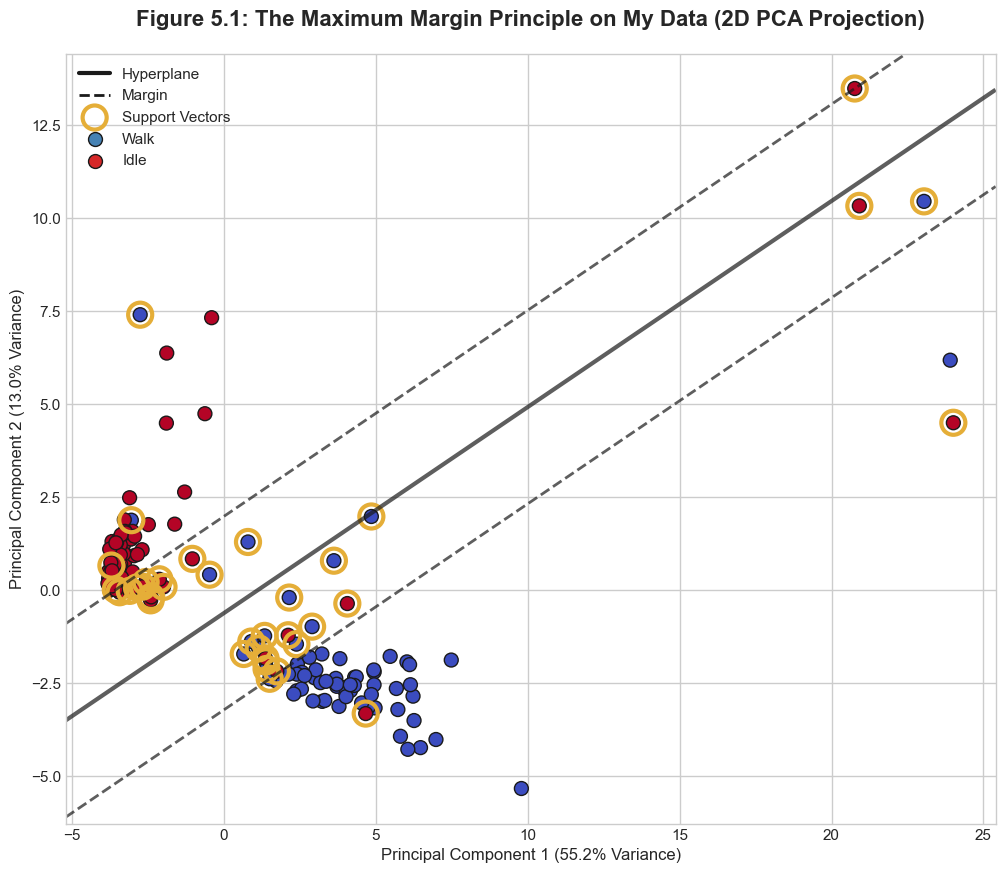

> A linear SVM trained on a 2D PCA projection of my `walk` (blue) and `idle` (red) data. 

The solid line is the decision boundary (the hyperplane), and the dashed lines represent the margin. The points circled in gold are the support vectors. While the model attempts to find the best-fitting line, it's clear that a simple linear boundary is insufficient; many points from both classes fall within the margin or on the wrong side entirely, demonstrating that my data is not linearly separable.

**The Soft Margin and the Kernel Trick**

Figure 5.1 clearly shows that my data is messy and not perfectly separable with a straight line. This is where two key SVM concepts become essential:

1.  **The Soft Margin:** I use a "soft-margin" SVM, which allows some points to be misclassified or fall within the margin. This is controlled by a hyperparameter `C`. A higher `C` value creates a stricter, narrower margin, while a lower `C` allows for a softer, wider margin that may generalize better. For the fast-paced gameplay of *Silksong*, I need a model that is robust to slight variations in my gestures, favoring a more generalizable (softer) margin. I chose `C=10` as a pragmatic balance.

2.  **The Kernel Trick:** The most powerful feature of the SVM is its ability to create non-linear decision boundaries using the **kernel trick**. I use the **Radial Basis Function (RBF) kernel**, which mathematically projects the data into an infinitely-dimensional space to find a separating hyperplane. In practice, this allows the decision boundary in the original space to be highly flexible and non-linear. The RBF kernel is defined as:
    $$
    K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)
    $$
    The `gamma` parameter controls how far the influence of a single training example reaches. This is what allows the model to learn the complex, curved "shape" that truly separates a `walk` from an `idle`.

The following figure provides the definitive, data-driven justification for this choice.

**Figure 5.2 & 5.3: Justifying the RBF Kernel with My Data**


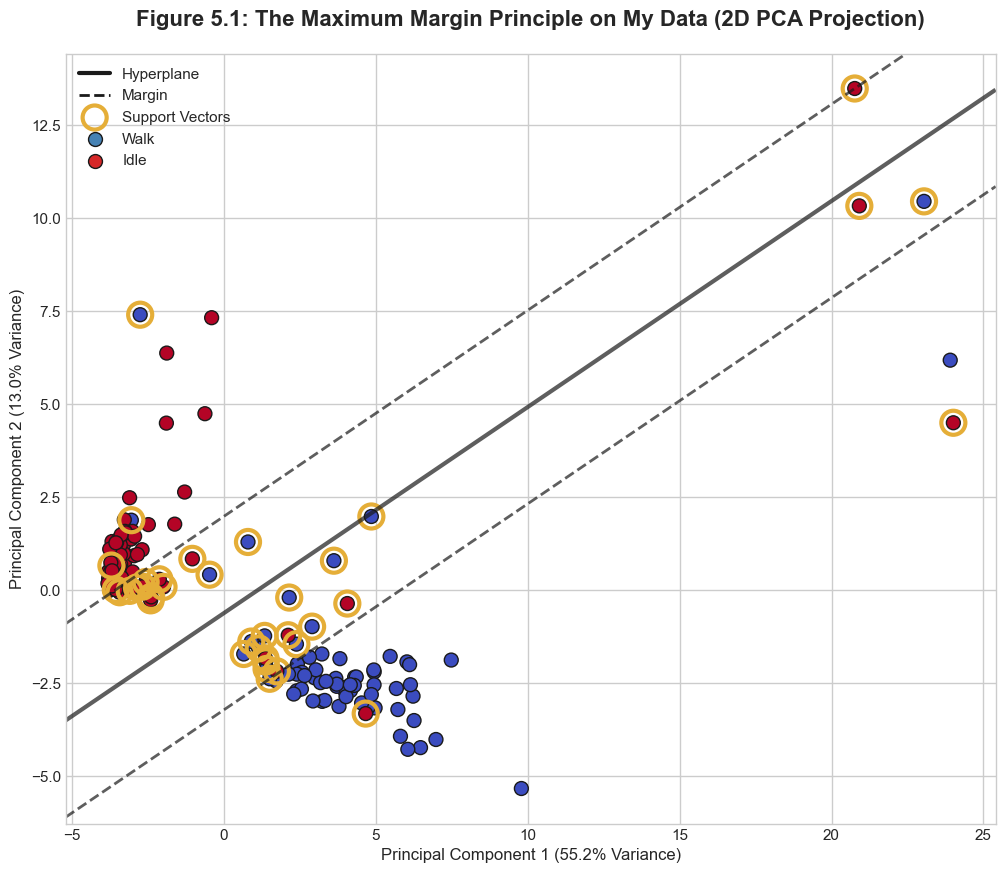

> A direct comparison between a Linear SVM (left) and an RBF Kernel SVM (right) on the same 2D-projected data. 

The shaded regions show how each model would classify new points. The Linear Kernel creates a simple, straight boundary that misclassifies a large number of points. In contrast, the RBF Kernel (right) learns a complex, non-linear boundary that successfully isolates the distinct clusters of `walk` and `idle` data. This visual evidence is the primary justification for my model selection.



#### 5.3 "…model initialization and construction…code block…" - Implementation

My implementation uses two distinct `scikit-learn` objects in sequence, directly reflecting the logic in my `SVM_Local_Training.py` script: a `StandardScaler` to normalize the data, followed by the `SVC` (Support Vector Classifier).

First, I initialize the `StandardScaler`. It is critical to fit this scaler **only on the training data** to prevent data leakage from the test set.


In [65]:
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler().fit(X_train)

# This scaler object is constructed and fit on the training data. It now
# contains the mean and standard deviation for each of the 48 features,
# and is ready to transform both the training and test sets consistently.
print("StandardScaler constructed and ready.")

StandardScaler constructed and ready.


Next, I initialize the `SVC` model with the RBF kernel and my chosen hyperparameters, which were just proven to be effective by the visualizations above.

In [67]:
from sklearn.svm import SVC

# This code initializes the Support Vector Classifier with my chosen parameters.
svm = SVC(
    # I use the 'rbf' kernel, which the visualization in Figure 5.3 proved
    # is necessary to capture the non-linear structure of my data.
    kernel="rbf",
    # The 'C' parameter is the regularization strength. I chose a value of 10
    # as a balance between a wide margin and correctly classifying training points.
    C=10,
    # 'gamma' defines the influence of each training sample. 'auto' sets
    # it to 1 / n_features, which is a sensible default.
    gamma="auto",
    # I enable probability estimates. For Silksong, this will allow me to set
    # a confidence threshold and reject uncertain predictions, preventing
    # accidental in-game actions.
    probability=True,
    # The random_state ensures reproducibility, particularly for the tie-breaking
    # logic used in the multiclass one-vs-one strategy.
    random_state=42,
)

print("Support Vector Classifier constructed and ready for training.")
print(svm)

Support Vector Classifier constructed and ready for training.
SVC(C=10, gamma='auto', probability=True, random_state=42)
